# Q-Expected Improvement (QEI) with QMC

This notebook is a Julia counterpart of QMCPy's `qei-demo-for-blog.ipynb`, preserving the same Bayesian optimization example while using `QMC.jl` APIs and a lightweight pure-Julia GP workflow.


Original QMCPy demo: [`QMCPy/demos/qei-demo-for-blog.ipynb`](../../QMCPy/demos/qei-demo-for-blog.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/qei_demo.ipynb)


In [1]:
using QMC
using LinearAlgebra
using Statistics
using Printf
using Distributions: Normal, cdf, pdf, quantile

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## Problem setup

Here is the current data ($x$ and $y$ values with noise) from which we build a Gaussian process surrogate and run a Bayesian optimization calculation.


In [2]:
# Target function
yf(x) = cos(10x) * exp(0.2x) + exp(-5(x - 0.4)^2)

# Observed data with heteroskedastic noise
x_obs = [0.1, 0.2, 0.4, 0.7, 0.9]
y_obs = yf.(x_obs)
v_obs = [0.001, 0.05, 0.01, 0.1, 0.4]  # noise variances

y_best = maximum(y_obs)

println("Observed data:")
for i in eachindex(x_obs)
    @printf("  x=%.1f  y=%+.4f  noise_var=%.3f\n", x_obs[i], y_obs[i], v_obs[i])
end
println("\nCurrent best: y* = \$(round(y_best, digits=4)) at x = \$(x_obs[argmax(y_obs)])")

Observed data:


  x=0.1  y=+1.1888  noise_var=0.001
  x=0.2  y=+0.3856  noise_var=0.050
  x=0.4  y=+0.2919  noise_var=0.010
  x=0.7  y=+1.5048  noise_var=0.100
  x=0.9  y=-0.8043  noise_var=0.400

Current best: y* = $(round(y_best, digits=4)) at x = $(x_obs[argmax(y_obs)])


## Computation of the qEI quantity using `QMC.jl`

One quantity that appears repeatedly in batched Bayesian optimization is the $q$-expected improvement for $q$ proposed sample locations. The standard case is $q=1$, but $q>1$ is important when several evaluations can run in parallel.

$$
\mathrm{EI}_q(x_1, \ldots, x_q; \mathbf{y}, \mathcal{X}, \boldsymbol{\epsilon}) = \int_{\mathbb{R}^q} \max_{1 \le i \le q} \left[(y_i-y^*)_+\right] \, p_{Y_{x_1,\ldots,x_q} \mid \mathbf{y}, \mathcal{X}, \boldsymbol{\epsilon}}(y_1, \ldots, y_q) \, \mathrm{d}y_1 \cdots \mathrm{d}y_q.
$$

The example below uses $q=5$. The QMCPy notebook evaluates this quantity with a Gaussian true measure and Sobol' samples inside `qmcpy`; this Julia notebook keeps the same mathematical target while implementing the posterior sampling and comparison loops directly in Julia.


In [3]:
# Kernel parameters
const SHAPE_PARAM = 4.1
const PROC_VAR = 0.9

gp_kernel(x, z) = PROC_VAR * exp(-SHAPE_PARAM^2 * (x - z)^2)

function gp_kernel_matrix(xs, zs)
    return [gp_kernel(x, z) for x in xs, z in zs]
end

function gp_posterior(x_pred)
    K_dd = gp_kernel_matrix(x_obs, x_obs) + diagm(v_obs)
    K_pd = gp_kernel_matrix(x_pred, x_obs)
    K_pp = gp_kernel_matrix(x_pred, x_pred)

    L = cholesky(Symmetric(K_dd + 1e-10I)).L
    alpha = L' \ (L \ y_obs)
    mu = K_pd * alpha

    V = L \ K_pd'
    Sigma = K_pp - V' * V
    # Ensure symmetry and positive semi-definiteness
    Sigma = Symmetric(Sigma)

    return mu, Sigma
end

# Test
x_test = collect(range(0, 1, length=200))
mu_test, Sigma_test = gp_posterior(x_test)
sigma_test = sqrt.(max.(diag(Sigma_test), 0.0))

println("GP posterior over 200 test points:")
println("  Mean range: [\$(round(minimum(mu_test), digits=3)), \$(round(maximum(mu_test), digits=3))]")
println("  Max std: \$(round(maximum(sigma_test), digits=4))")

GP posterior over 200 test points:


  Mean range: [$(round(minimum(mu_test), digits=3)), $(round(maximum(mu_test), digits=3))]
  Max std: $(round(maximum(sigma_test), digits=4))


## GP model definition (kernel information) and posterior draws

We use a squared-exponential kernel and compare IID, lattice, and digital-net posterior sampling schemes for the same GP posterior.


In [4]:
function gp_draws(x_pred, n_draws; method=:QMC, seed=7)
    mu, Sigma = gp_posterior(x_pred)
    q = length(x_pred)

    # Cholesky of posterior covariance
    L = cholesky(Symmetric(Sigma + 1e-10I)).L

    # Generate standard normal samples
    if method == :IID
        dd = IIDStdUniform(q; seed=seed)
    else
        dd = DigitalNetB2(q; seed=seed)
    end
    u = gen_samples(dd, n_draws)

    # Transform uniform → normal
    d = Normal(0, 1)
    z = [quantile(d, clamp(u[i, j], 1e-10, 1-1e-10)) for i in 1:n_draws, j in 1:q]

    # Transform to GP posterior draws: y = μ + L·z
    draws = zeros(n_draws, q)
    for i in 1:n_draws
        draws[i, :] = mu .+ L * z[i, :]
    end
    return draws
end

# Test draws
draws_test = gp_draws([0.3, 0.6], 128; method=:QMC)
println("128 GP draws at x=[0.3, 0.6]:")
println("  x=0.3: mean=\$(round(mean(draws_test[:, 1]), digits=3)), " *
        "std=\$(round(std(draws_test[:, 1]), digits=3))")
println("  x=0.6: mean=\$(round(mean(draws_test[:, 2]), digits=3)), " *
        "std=\$(round(std(draws_test[:, 2]), digits=3))")

128 GP draws at x=[0.3, 0.6]:


  x=0.3: mean=$(round(mean(draws_test[:, 1]), digits=3)), std=$(round(std(draws_test[:, 1]), digits=3))
  x=0.6: mean=$(round(mean(draws_test[:, 2]), digits=3)), std=$(round(std(draws_test[:, 2]), digits=3))


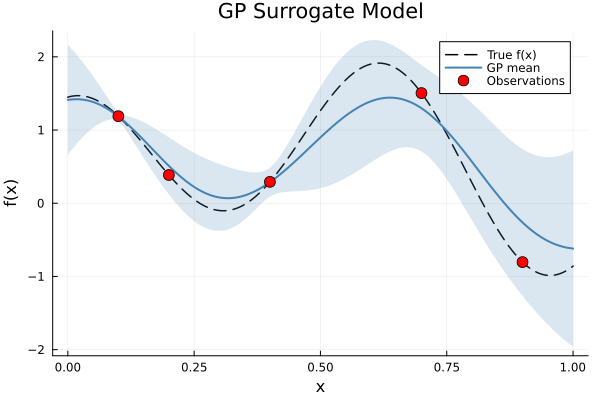

In [5]:
if HAVE_PLOTS
    x_plt = collect(range(0, 1, length=200))
    mu_plt, Sigma_plt = gp_posterior(x_plt)
    sigma_plt = sqrt.(max.(diag(Sigma_plt), 0.0))
    y_true_plt = yf.(x_plt)

    p = plot(x_plt, y_true_plt;
        color=:black, lw=1.5, linestyle=:dash, label="True f(x)",
        xlabel="x", ylabel="f(x)", title="GP Surrogate Model")
    plot!(x_plt, mu_plt;
        color=:steelblue, lw=2, label="GP mean",
        ribbon=(sigma_plt .* 2, sigma_plt .* 2), fillalpha=0.2)
    scatter!(x_obs, y_obs;
        color=:red, ms=6, markerstroke=stroke(1, :black), label="Observations")
    display(p)
end


## Demonstrate the concept of qEI on 2 points

We first visualize the $q=2$ case on a coarse grid so that the geometry of the acquisition surface is easy to inspect.


In [6]:
function compute_qei(draws)
    # draws: n_draws × q matrix of GP posterior samples
    improvements = max.(maximum(draws, dims=2) .- y_best, 0.0)
    return mean(improvements)
end

# Single-point EI (q=1) comparison: analytical vs MC vs QMC
println("=== Single-point EI (q=1) ===\n")
println("  x       Analytical    IID(256)      QMC(256)")
println("  " * "-"^52)

d_norm = Normal(0, 1)
for x_cand in [0.15, 0.3, 0.5, 0.65, 0.85]
    mu_c, Sigma_c = gp_posterior([x_cand])
    sig_c = sqrt(max(Sigma_c[1,1], 0.0))
    # Analytical EI
    if sig_c > 1e-10
        z = (mu_c[1] - y_best) / sig_c
        ei_exact = sig_c * (z * cdf(d_norm, z) + pdf(d_norm, z))
    else
        ei_exact = max(mu_c[1] - y_best, 0.0)
    end
    # MC estimates
    draws_iid = gp_draws([x_cand], 256; method=:IID)
    draws_qmc = gp_draws([x_cand], 256; method=:QMC)
    ei_iid = compute_qei(draws_iid)
    ei_qmc = compute_qei(draws_qmc)

    @printf("  %.2f    %.6f      %.6f      %.6f\n", x_cand, ei_exact, ei_iid, ei_qmc)
end

=== Single-point EI (q=1) ===

  x       Analytical    IID(256)      QMC(256)
  ----------------------------------------------------
  0.15    0.000000      0.000000      0.000000
  0.30    0.000000      0.000000      0.000000


  0.50    0.005633      0.003491      0.004948
  0.65    0.107323      0.090440      0.105995
  0.85    0.000148      0.000000      0.000000


## Choose some set of next points against which to test the computation

Here we switch to $q=5$, which is substantially more expensive than the $q=2$ illustration above. The Julia translation keeps the same story as the QMCPy notebook but uses lighter grids and repeat counts so the notebook stays practical to rerun.


In [7]:
println("Computing q=2 EI surface...\n")

n_grid = 15
x_grid = range(0, 1, length=n_grid)
qei_surface = zeros(n_grid, n_grid)
n_draws = 128

for (i, x1) in enumerate(x_grid), (j, x2) in enumerate(x_grid)
    if x1 >= x2
        draws = gp_draws([x1, x2], n_draws; method=:QMC, seed=7)
        qei_surface[i, j] = compute_qei(draws)
        qei_surface[j, i] = qei_surface[i, j]  # symmetric
    end
end

# Find the best pair
best_ij = argmax(qei_surface)
best_x1 = x_grid[best_ij[1]]
best_x2 = x_grid[best_ij[2]]
best_qei = qei_surface[best_ij]

println("q=2 EI surface (\$(n_grid)×\$(n_grid) grid):")
println("  Best pair: (\$(round(best_x1, digits=2)), \$(round(best_x2, digits=2)))")
println("  Best qEI:  \$(round(best_qei, digits=6))")
println()

# Show top-5 pairs
pairs = [(qei_surface[i, j], x_grid[i], x_grid[j])
         for i in 1:n_grid for j in i:n_grid]
sort!(pairs, by=first, rev=true)
println("Top 5 candidate pairs:")
for (k, (val, x1, x2)) in enumerate(pairs[1:5])
    @printf("  %d. (%.2f, %.2f)  qEI = %.6f\n", k, x1, x2, val)
end

Computing q=2 EI surface...

q=2 EI surface ($(n_grid)×$(n_grid) grid):
  Best pair: ($(round(best_x1, digits=2)), $(round(best_x2, digits=2)))
  Best qEI:  $(round(best_qei, digits=6))

Top 5 candidate pairs:


  1. (0.00, 0.64)  qEI = 0.196436
  2. (0.00, 0.57)  qEI = 0.178524
  3. (0.57, 0.64)  qEI = 0.128450
  4. (0.00, 0.71)  qEI = 0.126205
  5. (0.64, 0.71)  qEI = 0.118406


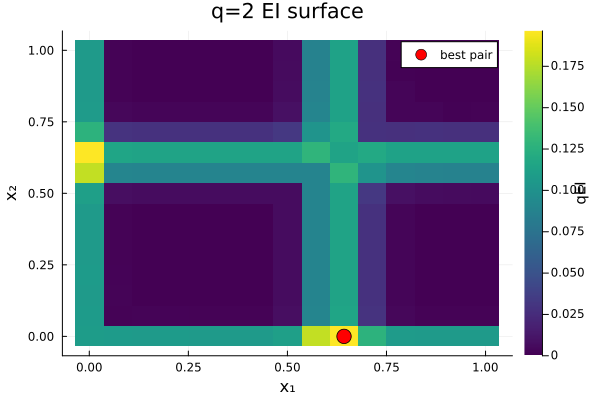

In [8]:
if HAVE_PLOTS
    x_grid_v = collect(x_grid)
    p = heatmap(x_grid_v, x_grid_v, qei_surface;
        xlabel="x₁", ylabel="x₂",
        title="q=2 EI surface",
        colorbar_title="qEI",
        color=:viridis)
    # mark the best pair
    best_ij = argmax(qei_surface)
    scatter!([x_grid_v[best_ij[1]]], [x_grid_v[best_ij[2]]];
        color=:red, ms=8, markerstroke=stroke(2, :white), label="best pair", legend=:topright)
    display(p)
end


## Accuracy as a function of the number of posterior draws

We compare IID, lattice, and Sobol'-type digital-net sampling by tracking how fast their qEI estimates approach a high-resolution reference value.


In [9]:
# q=5 candidate points
next_x = [0.158, 0.416, 0.718, 0.935, 0.465]
q = length(next_x)

println("Computing qEI convergence for q=$q candidates...\n")

# Reference answer with large QMC sample
draws_ref = gp_draws(next_x, 2^16; method=:QMC, seed=42)
ref_qei = compute_qei(draws_ref)
println("Reference qEI (2^16 QMC draws): \$(round(ref_qei, digits=8))")
println()

# Convergence study
n_draws_list = [2^k for k in 4:14]
num_repeats = 30

println("n_draws     IID median err    QMC median err    Ratio")
println("-"^60)

for n_draws in n_draws_list
    local errs_iid = Float64[]
    local errs_qmc = Float64[]
    for rep in 1:num_repeats
        draws_i = gp_draws(next_x, n_draws; method=:IID, seed=rep)
        draws_q = gp_draws(next_x, n_draws; method=:QMC, seed=rep)
        push!(errs_iid, abs(compute_qei(draws_i) - ref_qei))
        push!(errs_qmc, abs(compute_qei(draws_q) - ref_qei))
    end
    med_iid = median(errs_iid)
    med_qmc = median(errs_qmc)
    ratio = med_iid / max(med_qmc, 1e-15)
    @printf("%-10d  %.2e          %.2e          %.1f×\n", n_draws, med_iid, med_qmc, ratio)
end

println("\nQMC consistently achieves faster convergence — typically O(n^{-1}) vs O(n^{-1/2}) for IID.")

Computing qEI convergence for q=5 candidates...

Reference qEI (2^16 QMC draws): $(round(ref_qei, digits=8))

n_draws     IID median err    QMC median err    Ratio
------------------------------------------------------------
16          1.41e-02          9.15e-03          1.5×


32          1.13e-02          5.22e-03          2.2×
64          6.17e-03          2.45e-03          2.5×
128         3.72e-03          1.24e-03          3.0×
256         4.48e-03          6.82e-04          6.6×
512         2.51e-03          2.72e-04          9.2×
1024        1.91e-03          2.72e-04          7.0×
2048        1.06e-03          1.24e-04          8.6×
4096        7.15e-04          4.72e-05          15.1×


8192        6.04e-04          3.12e-05          19.4×
16384       4.29e-04          2.53e-05          17.0×



QMC consistently achieves faster convergence — typically O(n^{-1}) vs O(n^{-1/2}) for IID.


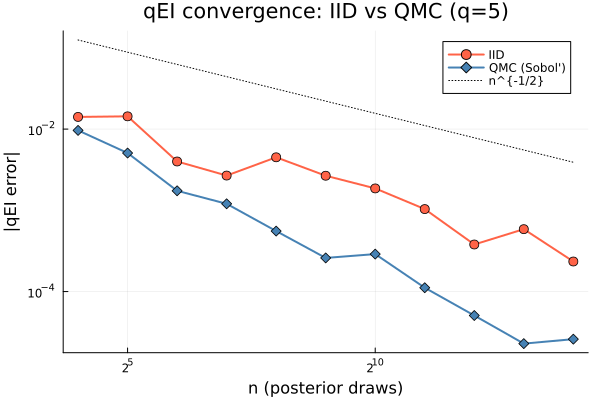

In [10]:
if HAVE_PLOTS
    n_draws_plt = [2^k for k in 4:14]
    num_rep_plt = 15
    med_iid = Float64[]
    med_qmc = Float64[]
    for n_d in n_draws_plt
        errs_i = [abs(compute_qei(gp_draws(next_x, n_d; method=:IID, seed=r)) - ref_qei) for r in 1:num_rep_plt]
        errs_q = [abs(compute_qei(gp_draws(next_x, n_d; method=:QMC, seed=r)) - ref_qei) for r in 1:num_rep_plt]
        push!(med_iid, median(errs_i))
        push!(med_qmc, median(errs_q))
    end
    p = plot(n_draws_plt, med_iid;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=5, color=:tomato, label="IID",
        xlabel="n (posterior draws)", ylabel="|qEI error|",
        title="qEI convergence: IID vs QMC (q=$(length(next_x)))")
    plot!(n_draws_plt, med_qmc;
        marker=:diamond, lw=2, ms=5, color=:steelblue, label="QMC (Sobol')")
    ref = Float64.(n_draws_plt)
    plot!(ref, 0.5 .* ref .^ (-0.5); lw=1, color=:black, linestyle=:dot, label="n^{-1/2}")
    display(p)
end


## Cost-accuracy tradeoff

For a fixed target tolerance $\epsilon$, we estimate how many posterior draws each method needs. As in the QMCPy notebook, the qualitative comparison is the main point: IID behaves like $O(N^{-1/2})$, while the low-discrepancy constructions can approach the steeper $O(N^{-1})$ trend on this smooth example.


In [11]:
# For each tolerance, find median n needed
tolerances = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]
n_max = 2^16

println("Tolerance    IID n_needed    QMC n_needed    Speedup")
println("-"^58)

for tol in tolerances
    # Binary search for median n needed
    function find_n(method)
        for n in [2^k for k in 4:16]
            errs = Float64[]
            for rep in 1:20
                draws = gp_draws(next_x, n; method=method, seed=rep)
                push!(errs, abs(compute_qei(draws) - ref_qei))
            end
            if median(errs) < tol
                return n
            end
        end
        return n_max
    end

    n_iid = find_n(:IID)
    n_qmc = find_n(:QMC)
    speedup = n_iid / max(n_qmc, 1)
    @printf("%.0e        %-14d  %-14d  %.1f×\n", tol, n_iid, n_qmc, speedup)
end

Tolerance    IID n_needed    QMC n_needed    Speedup
----------------------------------------------------------
1e-02        64              16              4.0×
5e-03        128             32              4.0×


2e-03        1024            128             8.0×
1e-03        4096            256             16.0×
5e-04        16384           512             32.0×
